In [2]:
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset
import torch

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Step 1: Load the CSV file into a DataFrame
#df = pd.read_csv('/content/drive/My Drive/overview-of-recordings.csv')
df = pd.read_csv('https://www.dropbox.com/scl/fi/qvzhk2zp8f2wpnz7hrqyd/overview-of-recordings.csv?rlkey=vugax3x2k76botbpberqbqzve&st=9omelcyw&dl=1')

df.head(10)

,audio_clipping,audio_clipping:confidence,background_noise_audible,background_noise_audible:confidence,overall_quality_of_the_audio,quiet_speaker,quiet_speaker:confidence,speaker_id,file_download,file_name,phrase,prompt,writer_id
0,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,43453425,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43453425_58166571.wav,When I remember her I feel down,Emotional pain,21665495
1,light_clipping,0.6803,no_noise,0.6803,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_43347848.wav,When I carry heavy things I feel like breaking...,Hair falling out,44088126
2,no_clipping,1.0000,no_noise,0.6655,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_53187202.wav,there is too much pain when i move my arm,Heart hurts,44292353
3,no_clipping,1.0000,light_noise,1.0000,3.33,audible_speaker,1.0,31349958,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_31349958_55816195.wav,My son had his lip pierced and it is swollen a...,Infected wound,43755034
4,no_clipping,1.0000,no_noise,1.0000,4.67,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_82524191.wav,My muscles in my lower back are aching,Infected wound,21665495
5,no_clipping,1.0000,no_noise,1.0000,3.00,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_51348478.wav,i have muscle pain that my back\nI Have Muscle...,Foot ache,44130352
6,no_clipping,1.0000,no_noise,1.0000,3.67,audible_speaker,1.0,40663048,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_40663048_42741720.wav,I have muscle pain in my left leg,Shoulder pain,43913997
7,no_clipping,1.0000,no_noise,1.0000,4.25,audible_speaker,1.0,15004831,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_15004831_21919890.wav,I have cut my finger because of playing footba...,Injury from sports,43318517
8,no_clipping,0.6978,no_noise,1.0000,3.67,audible_speaker,1.0,14353703,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_14353703_93481996.wav,I have acne in my face and other problems in m...,Skin issue,44066678
9,no_clipping,1.0000,no_noise,0.6879,3.33,audible_speaker,1.0,43719934,https://ml.sandbox.cf3.us/cgi-bin/index.cgi?do...,1249120_43719934_85316490.wav,I have a strange rash on my arm,Foot ache,44130352


In [ ]:
# Drop all columns except 'phrase' and 'prompt'
df = df[['phrase', 'prompt']]

# Display the DataFrame
print(df.head(10))

                                              phrase              prompt
0                    When I remember her I feel down      Emotional pain
1  When I carry heavy things I feel like breaking...    Hair falling out
2          there is too much pain when i move my arm         Heart hurts
3  My son had his lip pierced and it is swollen a...      Infected wound
4             My muscles in my lower back are aching      Infected wound
5  i have muscle pain that my back\nI Have Muscle...           Foot ache
6                  I have muscle pain in my left leg       Shoulder pain
7  I have cut my finger because of playing footba...  Injury from sports
8  I have acne in my face and other problems in m...          Skin issue
9                    I have a strange rash on my arm           Foot ache


In [ ]:
# Check if there are any empty values in the 'phrase' column
empty_phrase = df['phrase'].isna().any()

# Check if there are any empty values in the 'prompt' column
empty_prompt = df['prompt'].isna().any()

# Print the results
if empty_phrase:
    print("There are empty values in the 'phrase' column.")
else:
    print("There are no empty values in the 'phrase' column.")

if empty_prompt:
    print("There are empty values in the 'prompt' column.")
else:
    print("There are no empty values in the 'prompt' column.")

There are no empty values in the 'phrase' column.
There are no empty values in the 'prompt' column.


In [ ]:
num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 6661


In [ ]:
# Get the number of unique phrases (X)
num_unique_phrases = df['phrase'].nunique()

# Print the number of unique phrases
print("\nNumber of unique phrases (X):", num_unique_phrases)


Number of unique phrases (X): 706


In [ ]:
# Get the number of unique phrases (X)
num_unique_prompts = df['prompt'].nunique()

# Print the number of unique phrases
print("\nNumber of unique prompts (X):", num_unique_prompts)


Number of unique prompts (X): 25


In [ ]:
# Remove rows with duplicate combinations of 'phrase' and 'prompt'
df = df.drop_duplicates(subset=['phrase', 'prompt'])

num_rows = len(df)
print("Number of rows:", num_rows)

Number of rows: 707


In [ ]:
# Group the DataFrame by 'phrase' and count the number of unique prompts in each group
phrase_groups = df.groupby('phrase')['prompt'].nunique()

# Filter the groups where more than one unique prompt exists
duplicate_phrases = phrase_groups[phrase_groups > 1]

# Iterate through the duplicate phrases and print the corresponding rows
for phrase in duplicate_phrases.index:
    print(f"Phrase: {phrase}")
    print(df[df['phrase'] == phrase])
    print()

Phrase: I lose a lot of my hair
                      phrase            prompt
20   I lose a lot of my hair   Body feels weak
280  I lose a lot of my hair  Hair falling out



In [ ]:
# Drop the row at index 20, the prompt does not match the phrase
df = df.drop(20)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

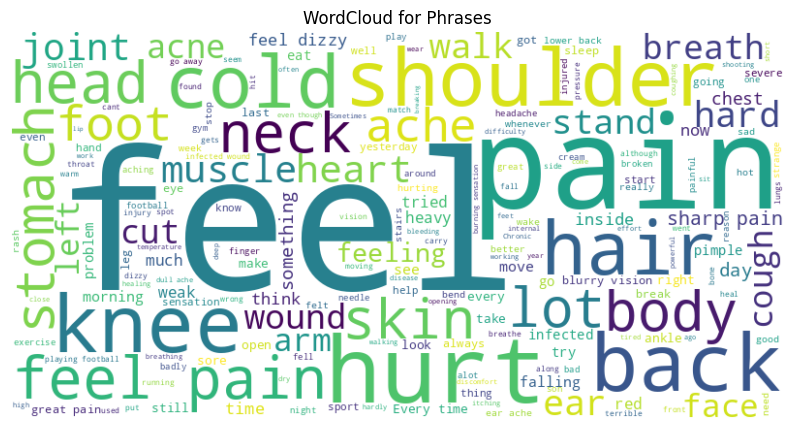

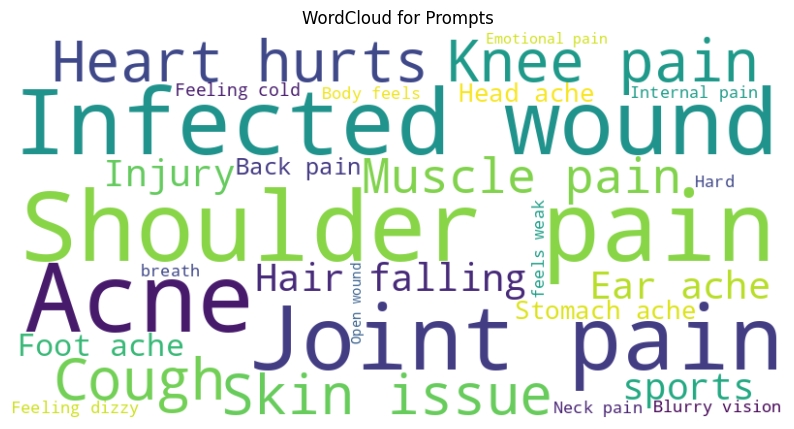

In [ ]:
# Concatenate all text from 'prompts' column into a single string
all_prompts = ' '.join(df['prompt'])

# Concatenate all text from 'phrases' column into a single string
all_phrases = ' '.join(df['phrase'])

# Create a WordCloud object for prompts
wordcloud_prompts = WordCloud(width=800, height=400, background_color='white').generate(all_prompts)

# Create a WordCloud object for phrases
wordcloud_phrases = WordCloud(width=800, height=400, background_color='white').generate(all_phrases)

# Plot WordCloud for phrases
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_phrases, interpolation='bilinear')
plt.title('WordCloud for Phrases')
plt.axis('off')
plt.show()

# Plot WordCloud for prompts
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud_prompts, interpolation='bilinear')
plt.title('WordCloud for Prompts')
plt.axis('off')
plt.show()

In [ ]:
import torch
from transformers import BertTokenizer, BertModel
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
X = df['phrase'].tolist()
y = df['prompt'].tolist()

# Load the pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [ ]:
# Tokenize and encode sentences
def preprocess_text(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    return inputs

# Generate embeddings for training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_inputs = [preprocess_text(text) for text in X_train]
X_test_inputs = [preprocess_text(text) for text in X_test]

X_train_embeddings = []
X_test_embeddings = []

# Generate embeddings using BERT model
with torch.no_grad():
    for inputs in X_train_inputs:
        outputs = model(**inputs)
        sentence_embedding = torch.mean(outputs.last_hidden_state, dim=1).squeeze().numpy()
        X_train_embeddings.append(sentence_embedding)

    for inputs in X_test_inputs:
        outputs = model(**inputs)
        sentence_embedding = torch.mean(outputs.last_hidden_state, dim=1).squeeze().numpy()
        X_test_embeddings.append(sentence_embedding)

# Standardize the data
scaler = StandardScaler()
X_train_embeddings_scaled = scaler.fit_transform(X_train_embeddings)
X_test_embeddings_scaled = scaler.transform(X_test_embeddings)


Accuracy: 0.6690140845070423


In [ ]:
from sklearn.svm import SVC

# Train a Support Vector Machine classifier on the training embeddings
svm_classifier = SVC()
svm_classifier.fit(X_train_embeddings_scaled, y_train)

# Predict on the testing data
y_pred_svm = svm_classifier.predict(X_test_embeddings_scaled)

# Evaluate the SVM model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)


SVM Accuracy: 0.6056338028169014


In [ ]:
# Train a logistic regression classifier on the training embeddings
classifier = LogisticRegression(max_iter=1000)  # Increase max_iter
classifier.fit(X_train_embeddings_scaled, y_train)

# Predict on the testing data
y_pred = classifier.predict(X_test_embeddings_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest classifier on the training embeddings
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_embeddings_scaled, y_train)

# Predict on the testing data
y_pred_rf = rf_classifier.predict(X_test_embeddings_scaled)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)


Random Forest Accuracy: 0.5


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train a Gradient Boosting Machine classifier on the training embeddings
gbm_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm_classifier.fit(X_train_embeddings_scaled, y_train)

# Predict on the testing data
y_pred_gbm = gbm_classifier.predict(X_test_embeddings_scaled)

# Evaluate the GBM model
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)
print("GBM Accuracy:", accuracy_gbm)


GBM Accuracy: 0.2605633802816901


In [ ]:
# Example new phrase
new_phrase = "Can't sleep, feeling restless and sore"

# Preprocess the new phrase
new_inputs = preprocess_text(new_phrase)

# Generate embedding for the new phrase using BERT model
with torch.no_grad():
    outputs = model(**new_inputs)
    new_embedding = torch.mean(outputs.last_hidden_state, dim=1).squeeze().numpy()

# Standardize the new embedding
new_embedding_scaled = scaler.transform([new_embedding])

# Predict the prompt for the new phrase
predicted_prompt = classifier.predict(new_embedding_scaled)

print("Predicted Prompt:", predicted_prompt)


Predicted Prompt: ['Body feels weak']


In [ ]:
# Example new phrase
new_phrase = "My knees hurt when I walk"

# Preprocess the new phrase
new_inputs = preprocess_text(new_phrase)

# Generate embedding for the new phrase using BERT model
with torch.no_grad():
    outputs = model(**new_inputs)
    new_embedding = torch.mean(outputs.last_hidden_state, dim=1).squeeze().numpy()

# Standardize the new embedding
new_embedding_scaled = scaler.transform([new_embedding])

# Predict the prompt for the new phrase
predicted_prompt = classifier.predict(new_embedding_scaled)

print("Predicted Prompt:", predicted_prompt)

Predicted Prompt: ['Joint pain']
